<a href="https://colab.research.google.com/github/hania280/FlightReservation/blob/main/PythonGame.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
print("Welcome to my First Game!")
name = input("What is your Name?")
age = int(input("What is your Age?"))
print("Hello", name, "you are", age, "years old")
health = 10
# Fixed: Added f-string for correct string and variable concatenation
print(f"You are starting with, {health} Health")

if age >= 18:
  print("You are old enough!")
  # Converted input to lowercase once for easier comparison
  wants_To_play = input("Do you want to play? (yes/no) ").lower()

  if wants_To_play == "yes":
    print("Let's Play!")
    left_or_right = input("First choice... Left or Right (left/right)? ").lower()

    if left_or_right == "left":
      ans = input("Nice, you follow the path and reach a lake... Do you swim across or go around (across/around)? ").lower()

      if ans == "around":
        print("You went around and reached the other way")
      # Fixed: Corrected indentation for elif
      elif ans == "across":
        print("You managed to move across, but were bit by a snake and lost 5 health")
        health -= 5
        if health <= 0:
          print("You have now 0 health and you lost")
        else:
          ans = input("You notice a house and a river. Which do you go to (river/house)? ").lower()

          if ans == "house":
            print("You went inside the house and the owner does not like you....lose 5 health")
            health -= 5
            if health <= 0:
              print("You have now 0 health and you lost")
            else:
              print("You have survived this encounter.")
          # Added handling for 'river' choice
          elif ans == "river":
            print("You fell in and lost 5 health")
            health -= 5
            if health <= 0:
              print("You have now 0 health and you lost")
            else:
              print("You managed to get out of the river but lost some health.")
          else:
            print("Invalid choice for house/river. You are lost!")

      else:
        print("Invalid choice for lake. You fell down and lost!")
        health = 0

    # Added handling for 'right' choice
    elif left_or_right == "right":
      print("You chose right and fell down a cliff! You lost!")
      health = 0
    else:
      print("Invalid choice for first path. You fell down and lost!")
      health = 0

  else:
    # Fixed: Corrected indentation for else block
    print("See you later")
else:
  print("You are not old enough!")

# Final game outcome based on health and path taken
if health <= 0:
  print("Game Over!")
elif age >= 18 and wants_To_play == "yes":
  print(f"Congratulations! You finished the game with {health} health.")


Welcome to my First Game!
What is your Name?Hania
What is your Age?20
Hello Hania you are 20 years old
You are starting with, 10 Health
You are old enough!
Do you want to play? (yes/no) yes
Let's Play!
First choice... Left or Right (left/right)? left
Nice, you follow the path and reach a lake... Do you swim across or go around (across/around)? around
You went around and reached the other way
Congratulations! You finished the game with 10 health.


### 1. Generate Synthetic Data

First, let's create a simple dataset with a linear relationship and some noise. We'll use `make_regression` from `sklearn.datasets`.

In [4]:
from sklearn.datasets import make_regression
import pandas as pd

# Generate 100 samples with 1 feature
X, y = make_regression(n_samples=100, n_features=1, noise=20, random_state=42)

# Convert to DataFrame for easier handling (optional, but good practice)
df = pd.DataFrame({'feature': X[:, 0], 'target': y})

print("First 5 rows of the generated data:")
display(df.head())

First 5 rows of the generated data:


,feature,target
0,0.931280,62.687202
1,0.087047,-23.763981
2,-1.057711,-25.686766
3,0.314247,7.936457
4,-0.479174,-15.475495


### 2. Split Data into Training and Testing Sets

It's crucial to split your data to evaluate the model's performance on unseen data. We'll use `train_test_split`.

In [5]:
from sklearn.model_selection import train_test_split

# Split the data with 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data samples: {len(X_train)}")
print(f"Testing data samples: {len(X_test)}")

Training data samples: 80
Testing data samples: 20


### 3. Define and Train a Simple Model (Linear Regression)

We'll use `LinearRegression` from `sklearn.linear_model`, which is a common choice for simple regression tasks.

In [6]:
from sklearn.linear_model import LinearRegression

# Create a Linear Regression model instance
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("Model training complete.")
print(f"Model coefficient (slope): {model.coef_[0]:.2f}")
print(f"Model intercept: {model.intercept_:.2f}")

Model training complete.
Model coefficient (slope): 46.75
Model intercept: 0.20


### 4. Make Predictions

Now, let's use our trained model to make predictions on the unseen test data.

In [7]:
# Make predictions on the test set
y_pred = model.predict(X_test)

print("First 5 actual vs. predicted values on the test set:")
for i in range(5):
    print(f"Actual: {y_test[i]:.2f}, Predicted: {y_pred[i]:.2f}")

First 5 actual vs. predicted values on the test set:
Actual: -42.46, Predicted: -61.89
Actual: 116.38, Predicted: 69.29
Actual: 54.90, Predicted: 38.18
Actual: 4.54, Predicted: -18.13
Actual: -5.48, Predicted: -10.75


### 5. Evaluate the Model

To assess how well our model performed, we'll use common regression metrics like Mean Squared Error (MSE) and R-squared (`r2_score`).

In [8]:
from sklearn.metrics import mean_squared_error, r2_score

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Calculate R-squared score
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

Mean Squared Error (MSE): 416.81
R-squared (R2) Score: 0.80


### 6. Visualize the Results

Visualizing the predictions against the actual values can give a good intuition about the model's performance.

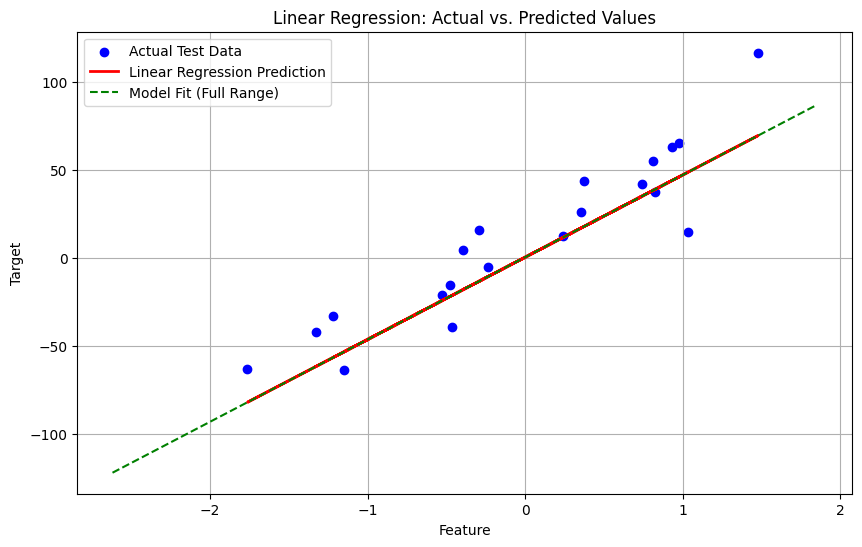

In [9]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Test Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Linear Regression Prediction')

# Also plot the entire dataset and the model's line to see the fit
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model.predict(x_line)
plt.plot(x_line, y_line, color='green', linestyle='--', label='Model Fit (Full Range)')

plt.xlabel('Feature')
plt.ylabel('Target')
plt.title('Linear Regression: Actual vs. Predicted Values')
plt.legend()
plt.grid(True)
plt.show()